In [ ]:
# imports and utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
from matplotlib.patches import Patch, Rectangle
from matplotlib.cm import ScalarMappable

indices = {
      0 : (4,7-7),
      1 : (4,7-6),
      2 : (7,7-5),
      3 : (5,7-7),
      4 : (5,7-4),
      5 : (5,7-5),
      6 : (4,7-4),
      7 : (7,7-7),
      8 : (6,7-6),
      9 : (7,7-4),
      10 : (5,7-6),
      11 : (6,7-4),
      12 : (4,7-5),
      13 : (6,7-5),
      14 : (6,7-7),
      15 : (7,7-6),
      16 : (3,7-7),
      17 : (3,7-6),
      18 : (2,7-7),
      19 : (2,7-6),
      20 : (0,7-7),
      21 : (1,7-7),
      22 : (0,7-6),
      23 : (1,7-6),
      24 : (3,7-5),
      25 : (1,7-5),
      26 : (2,7-5),
      27 : (4,7-3),
      28 : (0,7-5),
      29 : (3,7-4),
      30 : (0,7-4),
      31 : (1,7-4),
      32 : (2,7-4),
      33 : (3,7-3),
      34 : (2,7-3),
      35 : (0,7-3),
      36 : (1,7-3),
      37 : (0,7-2),
      38 : (5,7-3),
      39 : (1,7-2),
      40 : (2,7-2),
      41 : (3,7-2),
      42 : (1,7-1),
      43 : (0,7-1),
      44 : (0,7-0),
      45 : (3,7-1),
      46 : (1,7-0),
      47 : (2,7-1),
      48 : (3,7-0),
      49 : (2,7-0),
      50 : (6,7-2),
      51 : (6,7-1),
      52 : (7,7-1),
      53 : (4,7-1),
      54 : (5,7-1),
      55 : (6,7-0),
      56 : (7,7-0),
      57 : (7,7-2),
      58 : (7,7-3),
      59 : (4,7-2),
      60 : (5,7-0),
      61 : (5,7-2),
      62 : (6,7-3),
      63 : (4,7-0),
      64:(3+8,7),
      65:(3+8,6),
      66:(2+8,4),
      67:(2+8,6),
      68:(3+8,4),
      69:(1+8,7),
      70:(1+8,5),
      71:(0+8,7),
      72:(1+8,6),
      73:(3+8,3),
      74:(2+8,7),
      75:(2+8,3),
      76:(3+8,5),
      77:(0+8,5),
      78:(2+8,5),
      79:(0+8,6),
      80:(4+8,7),
      81:(6+8,7),
      82:(5+8,7),
      83:(7+8,7),
      84:(5+8,6),
      85:(4+8,6),
      86:(6+8,6),
      87:(7+8,6),
      88:(4+8,5),
      89:(6+8,5),
      90:(5+8,5),
      91:(1+8,4),
      92:(7+8,5),
      93:(7+8,4),
      94:(6+8,4),
      95:(4+8,4),
      96:(5+8,4),
      97:(5+8,3),
      98:(6+8,3),
      99:(4+8,3),
      100:(7+8,3),
      101:(7+8,2),
      102:(0+8,4),
      103:(6+8,2),
      104:(7+8,1),
      105:(5+8,2),
      106:(6+8,1),
      107:(4+8,2),
      108:(7+8,0),
      109:(5+8,1),
      110:(6+8,0),
      111:(4+8,1),
      112:(5+8,0),
      113:(4+8,0),
      114:(0+8,2),
      115:(2+8,1),
      116:(0+8,1),
      117:(3+8,1),
      118:(1+8,1),
      119:(1+8,0),
      120:(0+8,0),
      121:(1+8,2),
      122:(1+8,3),
      123:(3+8,2),
      124:(2+8,0),
      125:(2+8,2),
      126:(0+8,3),
      127:(3+8,0)}
indices_swapped = {}
for k, v in indices.items():
    if 0 <= k <= 63:
        indices_swapped[k+64] = v
    elif 64 <= k <= 127:
        indices_swapped[k-64] = v
#indices = indices_swapped

def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeak(hist, bins):
    photopeak = 0
    for i in range(1, len(hist)-4):
        #if hist[-1*i] > hist[-1*(i+1)] and hist[-1*i] > hist[-1*(i+2)] and hist[-1*i] >= 0.5 * np.max(hist):
        if hist[-1*i] >= 0.5 * np.max(hist[len(hist) // 4:]):
            photopeak = len(hist)-1*i
            break
    fit_p = [0,1,1]
    fit_x = list(bins[photopeak-5:photopeak+10])
    fit_y = list(hist[photopeak-5:photopeak+10])

    if len(fit_x) != 0 and len(fit_y) != 0:
        try:
            fit_p, _ = curve_fit(gaussian, fit_x, fit_y, p0=[max(fit_y)*0.8, bins[photopeak], 2])
        except:
            pass
    return fit_p


colors = ['blue', 'red', 'green', 'orange']

In [392]:
# Read in data
data_dirs = [
    #'GAGG/LYSO60min.dat',
    #'GAGG/GAGG60min.dat',
    #'GAGG/LYSOov2.dat',
    #'GAGG/GAGGov2.dat',
    'ctr2.dat'
]
names = ['', 'GAGG', 'LYSOov2', 'GAGGov2', 'ctr']
datas = []
for data_dir in data_dirs:
    print(data_dir)
    df = pd.read_csv(data_dir, header=None, sep = '\t', usecols = [2, 3, 4, 7, 8, 9])
    df.columns = ['TimeL', 'EnergyL', 'IDL', 'TimeR', 'EnergyR', 'IDR']
    df['TimeDiff'] = df['TimeL'] - df['TimeR']
    datas.append(np.asarray(df))

ctr2.dat


18637


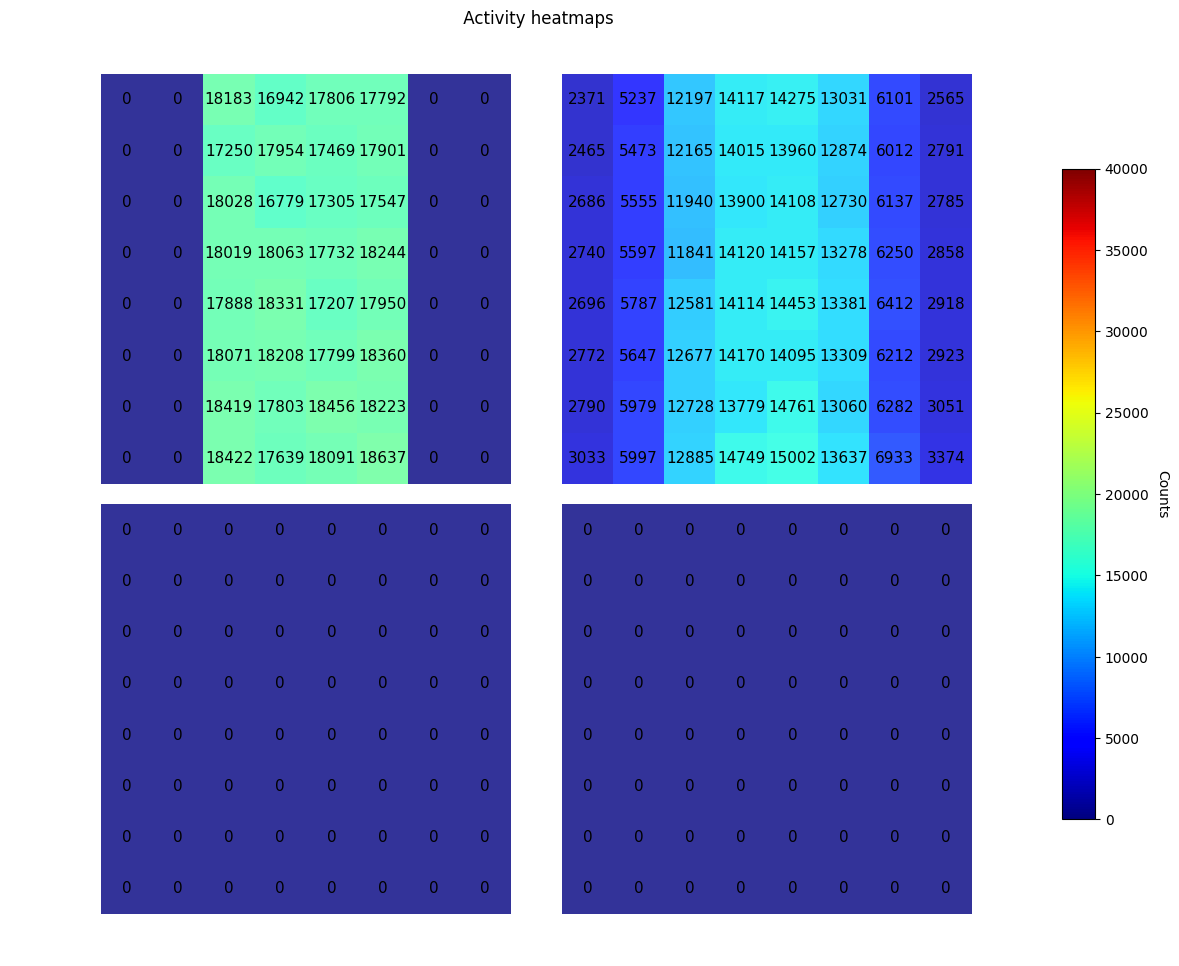

In [449]:
# Activity heatmaps
reldata = datas_cut # Can change this to datas (for full modules) or datas_cut (for upper 64)
#reldata = datas_pcut
#reldata = datas

for name, data in zip(names, reldata):
    eventcountsL = np.zeros((128* 2), dtype=np.int32)
    eventcountsR = np.zeros((128* 2), dtype=np.int32)
    idls = np.asarray(data[:, 2] % 128, dtype=np.int32)
    idrs = np.asarray(data[:, 5] % 128, dtype=np.int32)
    np.add.at(eventcountsL, idls, 1)
    np.add.at(eventcountsR, idrs, 1)
    max_val = np.max((eventcountsL, eventcountsR))
    print(max_val)
    max_val = 40000
        
    fig, ax = plt.subplots(figsize=(14, 12))
    for n in range(0, 128):
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        colorL = plt.cm.jet(eventcountsL[n] / max_val)
        #colorL = plt.cm.jet(n / 128)
        colorR = plt.cm.jet(eventcountsR[n] / max_val)
        #colorR = plt.cm.jet(n / 128)
        rectl = Rectangle((x, y), 1, 1, linewidth=0.0, edgecolor='black', facecolor=colorL, alpha=0.8)
        ax.add_patch(rectl)
        ax.text(x + 0.5, y + 0.5, eventcountsL[n], fontsize=11, ha='center', va='center')
        y, x = indices[(n + 64) % 128]
        x = 7 - x
        if y >= 8:
            y += 0.4
        rectr = Rectangle((x + 9, y), 1, 1, linewidth=0.0, edgecolor='black', facecolor=colorR, alpha=0.8)
        ax.add_patch(rectr)
        ax.text(x + 9.5, y + 0.5, eventcountsR[n], fontsize=11, ha='center', va='center')

    plt.tick_params(axis='both', which='both', bottom=False, top=False,
                    left=False, right=False, labelbottom=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.ylim(0, 16)
    plt.xlim(0, 8)
    plt.axis('equal')

    # Add colorbar
    sm = ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=0, vmax = max_val))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.0)
    cbar.set_label('Counts', rotation=270, labelpad=15)

    plt.title(f'{name} Activity heatmaps')
    plt.show()

In [439]:
# Cut for only events in idl 0-63 and idr 0-63
module_ids = [k for k, v in indices.items() if v[1] in [2, 3, 4, 5]]
#module_ids = [k for k, v in indices_swapped.items() if v[1] in [1, 2, 3, 4, 5]]
#module_ids = [0]
datas_cut = []
for data in datas:
    mask = (data[:, 2] % 128 < 64) & (data[:, 5] % 128 < 64) & (np.isin(data[:, 2] % 128, module_ids))
    #mask = (data[:, 2] % 128 < 64) & (data[:, 5] % 128 < 64) & (np.isin(data[:, 5] % 128, module_ids))
    #mask = (data[:, 2] % 128 < 64) & (data[:, 5] % 128 < 64)
    #mask = (data[:, 2] % 128 >= 64) & (data[:, 5] % 128 >= 64)
    datas_cut.append(data[mask])
    print(len(datas_cut[-1]))

572518


In [11]:
print(datas[0][0:5])

[[ 6.47432873e+12  2.93957100e+01  9.13000000e+02  6.47432873e+12
   3.07291400e+00  1.13000000e+02 -2.32500000e+03]
 [ 6.47445997e+12  3.32666780e+01  9.53000000e+02  6.47445996e+12
   2.72865100e+01  8.80000000e+01  1.39200000e+03]
 [ 6.47474008e+12  2.92948000e+01  9.91000000e+02  6.47474008e+12
   3.22035750e+01  9.40000000e+01  1.59000000e+02]
 [ 6.47506843e+12  1.83108440e+01  8.98000000e+02  6.47506843e+12
   2.05187380e+01  1.13000000e+02 -8.74000000e+02]
 [ 6.47509262e+12  4.83828000e+00  9.83000000e+02  6.47509262e+12
   6.11397600e+00  7.20000000e+01  2.57000000e+02]]


In [272]:
# Storing energy resolution, num events, num events in peak for each channel
# Reset these before running next 2 cells
eres = [[] for _ in range(len(datas))]
photopeaks = [[] for _ in range(len(datas))]
nevents = [[] for _ in range(len(datas))]
neventsinpeak = [[] for _ in range(len(datas))]

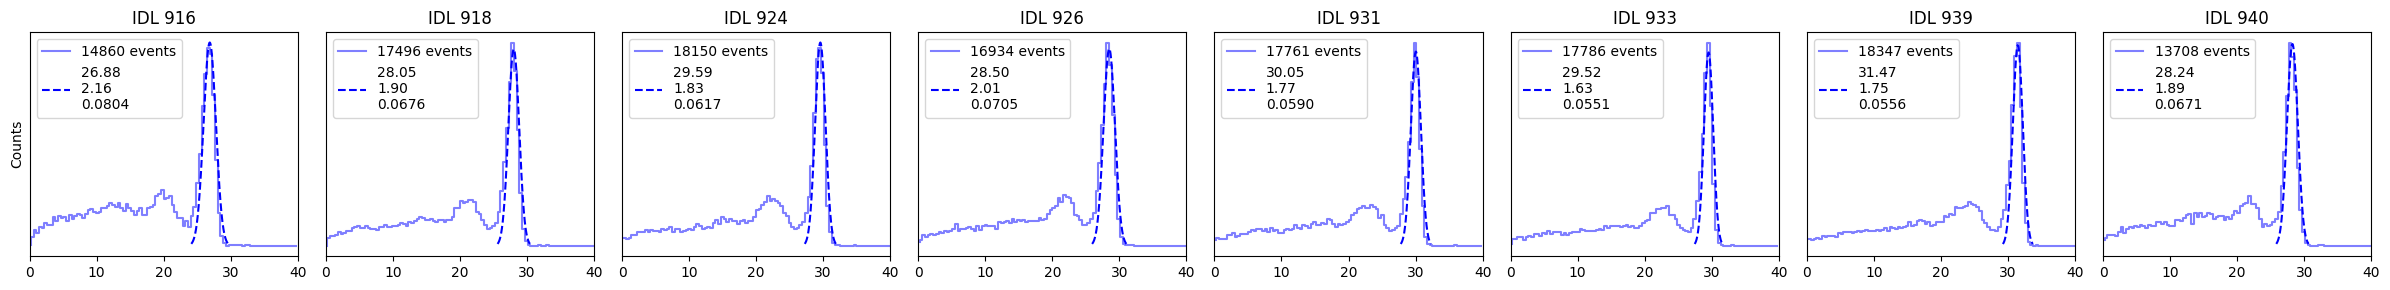

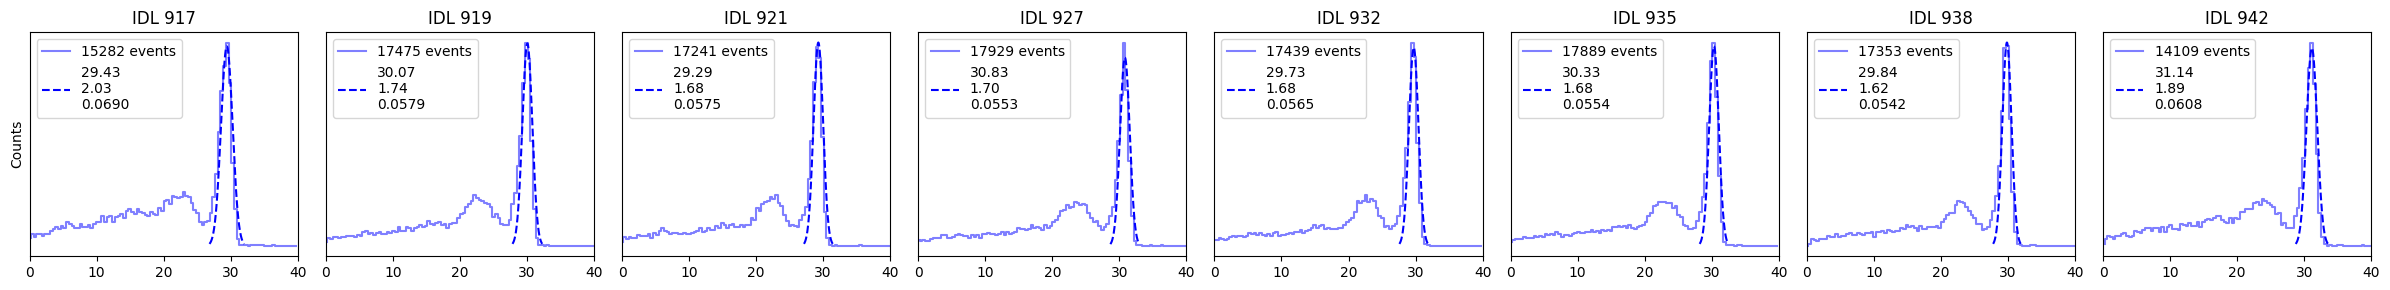

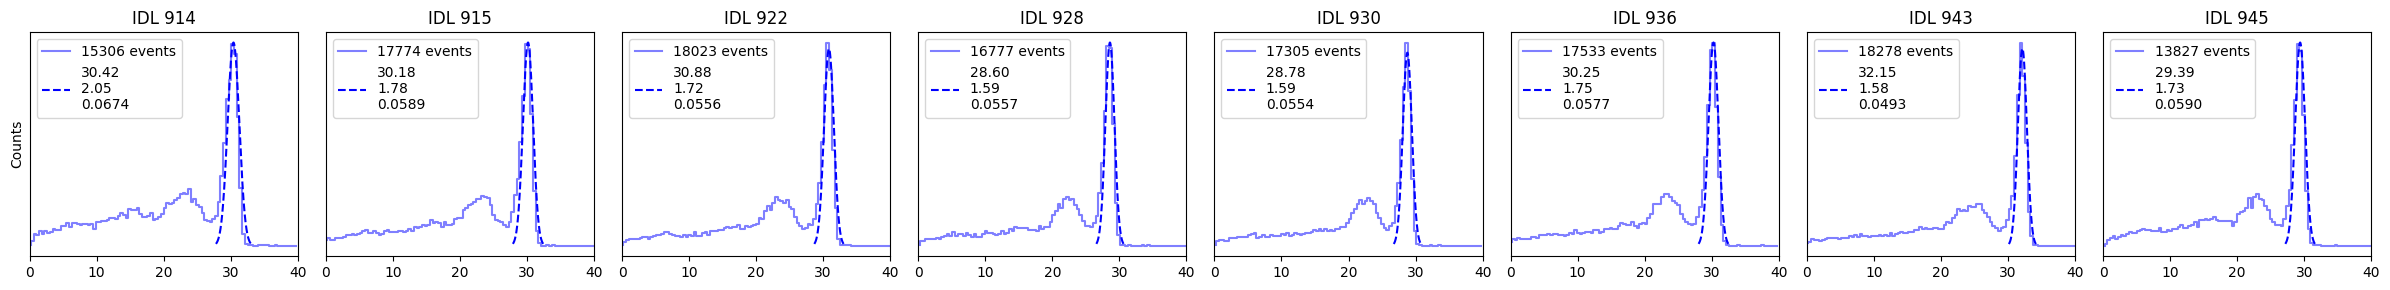

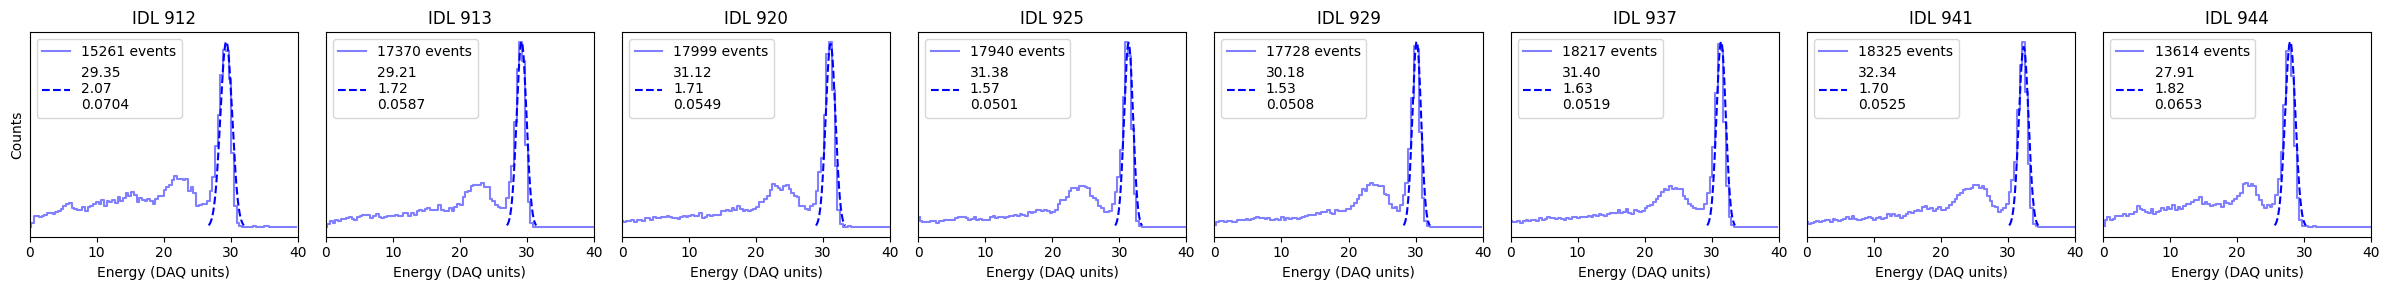

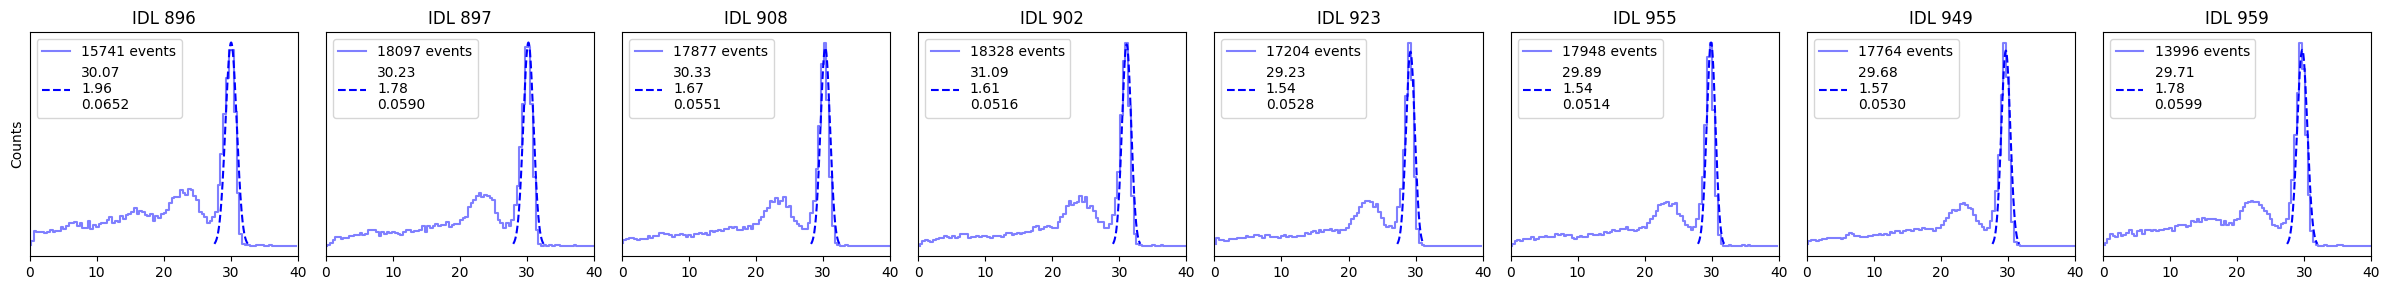

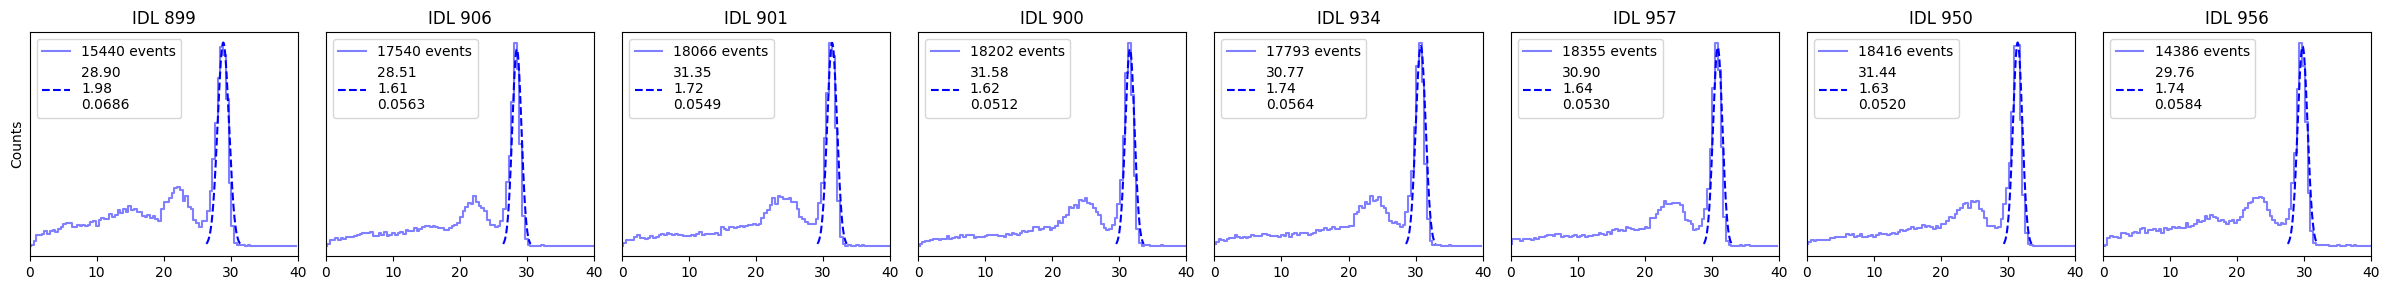

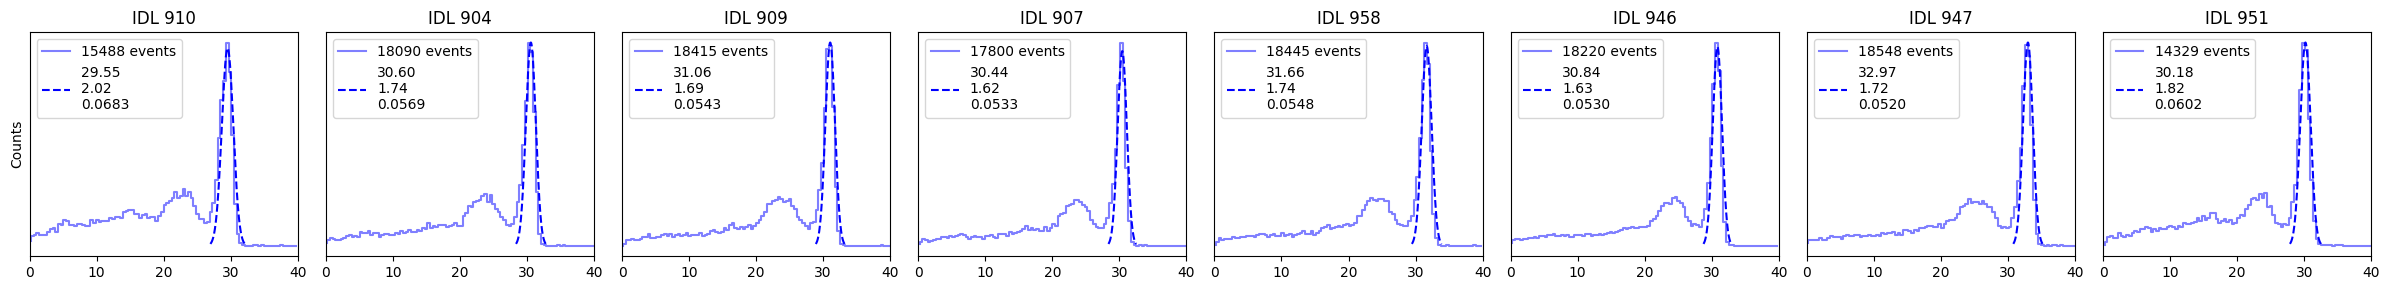

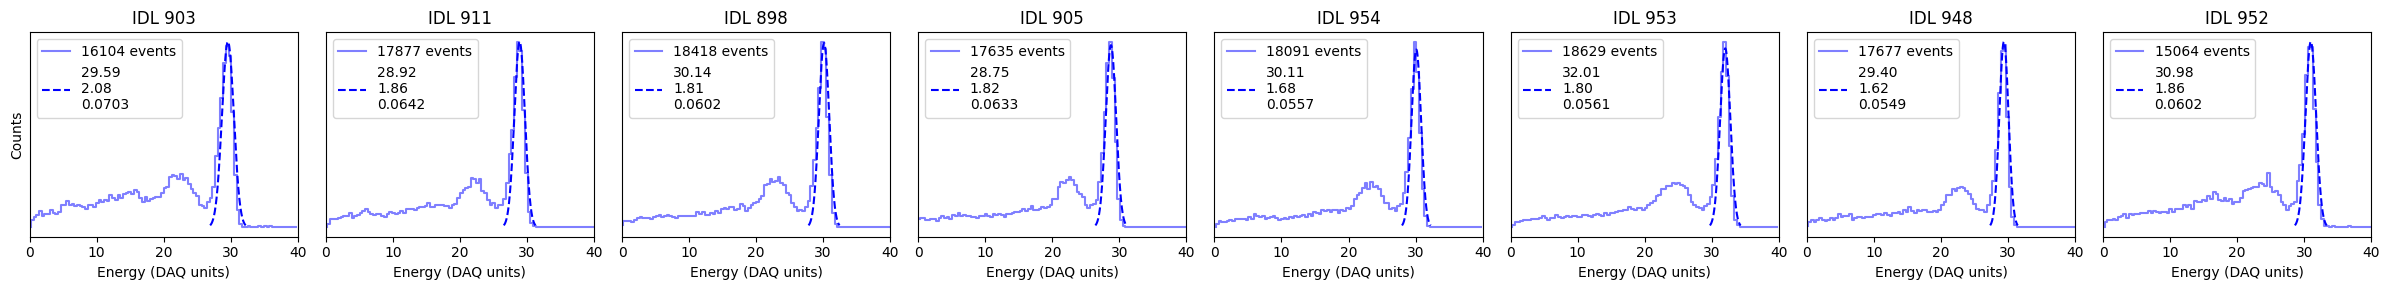

In [276]:
# Left module energy histograms
bins = np.linspace(0, 40, 100)
bincenters = (bins[:-1] + bins[1:]) / 2
for row in range(0, 8):
    list_indices = dict(sorted(
        ((k, v) for k, v in indices.items() if v[0] == row),
        key=lambda item: item[1][1]
    ))
    list_indices = list(list_indices.keys())
    fig, subplots = plt.subplots(1, 8, figsize=(24, 3))
    subplots = subplots.flatten()
    for i in range(8):
        id6 = list_indices[i] + 896
        for dat, color, n in zip(datas_cut, colors, range(len(datas))):
            energies6 = dat[:, 1][dat[:, 2] == id6]
            hist, _ = np.histogram(energies6, bins=bins, range=(0, 40))
            subplots[i].step(bincenters, hist, color=color, alpha=0.5, label = f'{np.sum(hist)} events')
            if len(energies6) > 0:
                fit_p = findPhotopeak(hist, bincenters)
                plotting_bounds = np.linspace(fit_p[1] - 3 * fit_p[2], fit_p[1] + 3 * fit_p[2], 1000)
                fwhm = fit_p[2]*2.355
                energy_resolution = fwhm / fit_p[1]
                subplots[i].plot(plotting_bounds, gaussian(plotting_bounds, *fit_p), color=color, linestyle='--', label=f'{fit_p[1]:.2f}\n{fwhm:.2f}\n{energy_resolution:.4f}')
                eres[n].append(energy_resolution)
                photopeaks[n].append(fit_p[1])
                nevents[n].append(len(energies6))
                mask = (energies6 > fit_p[1] - 2.5 * fit_p[2]) & (energies6 < fit_p[1] + 2.5 * fit_p[2])
                neventsinpeak[n].append(np.sum(mask))
             
        subplots[i].set_title(f'IDL {id6}')
        subplots[i].legend()
       
    for i in range(8):
        subplots[i].set_xlim(0, 40)
        subplots[i].set_yticks([])
        if list_indices[i] + 896 == 852:
            subplots[i].set_ylim(0, 30)
        if i % 8 == 0:
            subplots[i].set_ylabel('Counts')
        if row % 4 == 3:
            subplots[i].set_xlabel('Energy (DAQ units)')

    plt.tight_layout()
    plt.show()

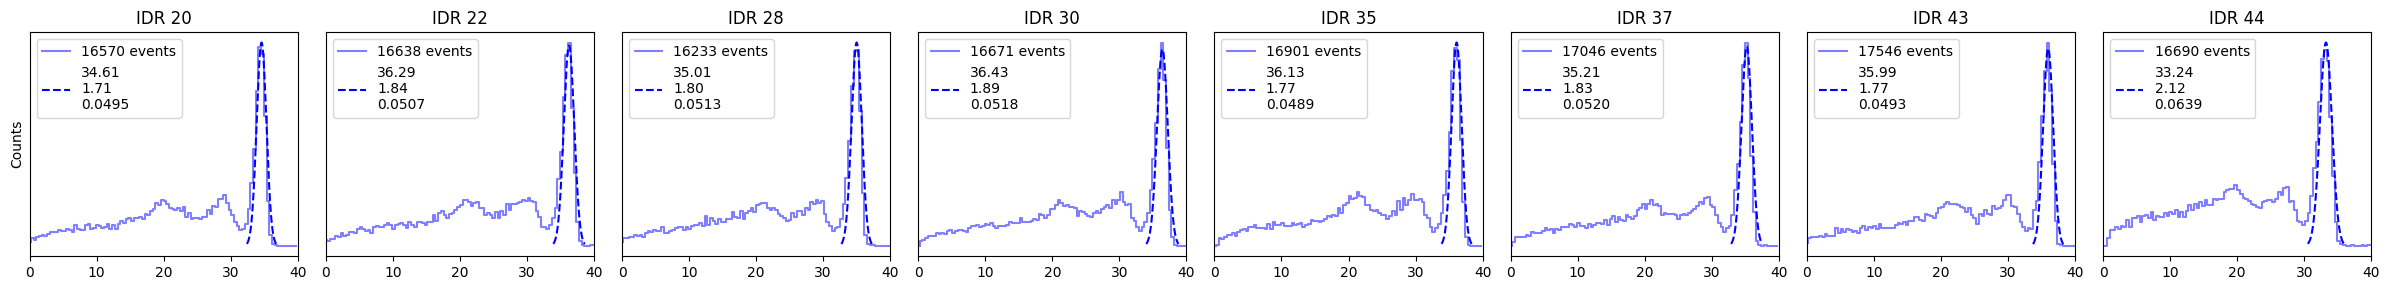

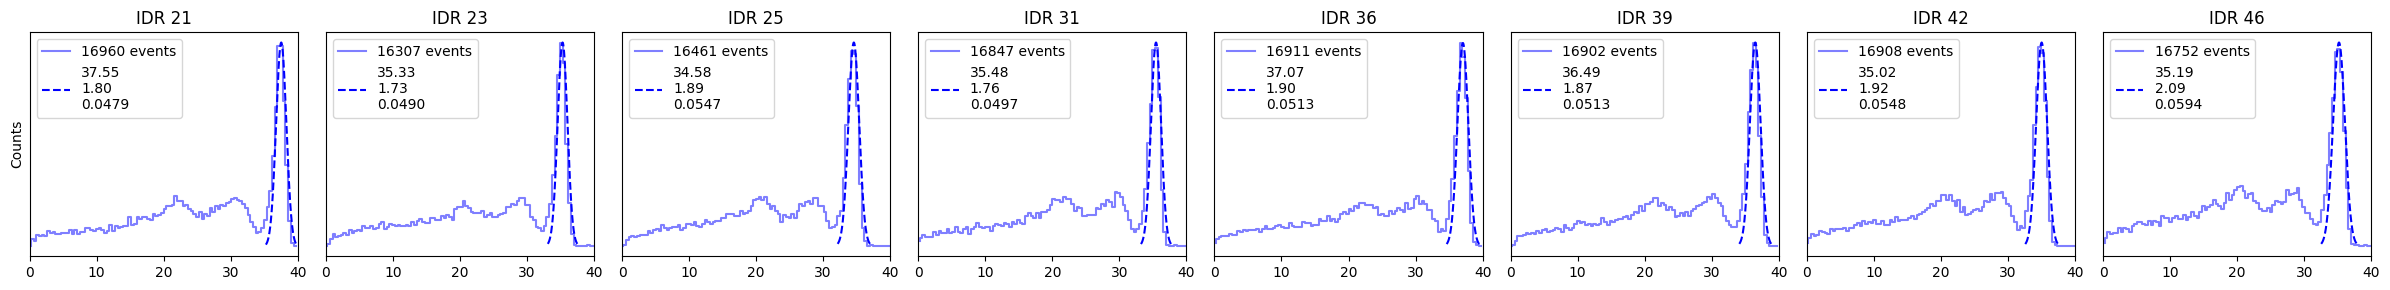

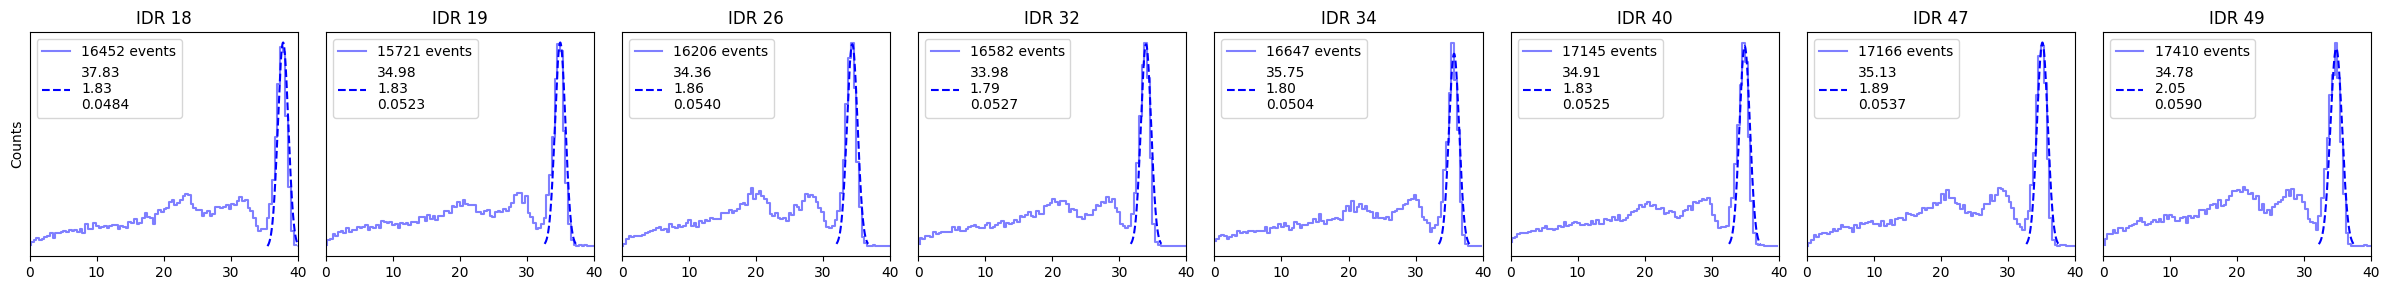

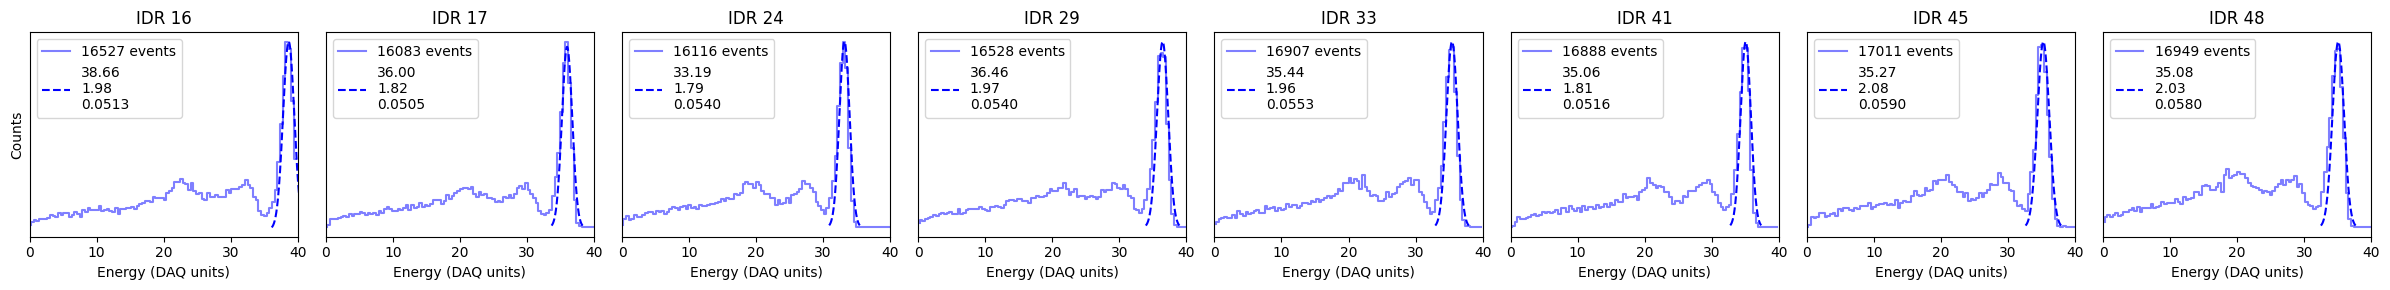

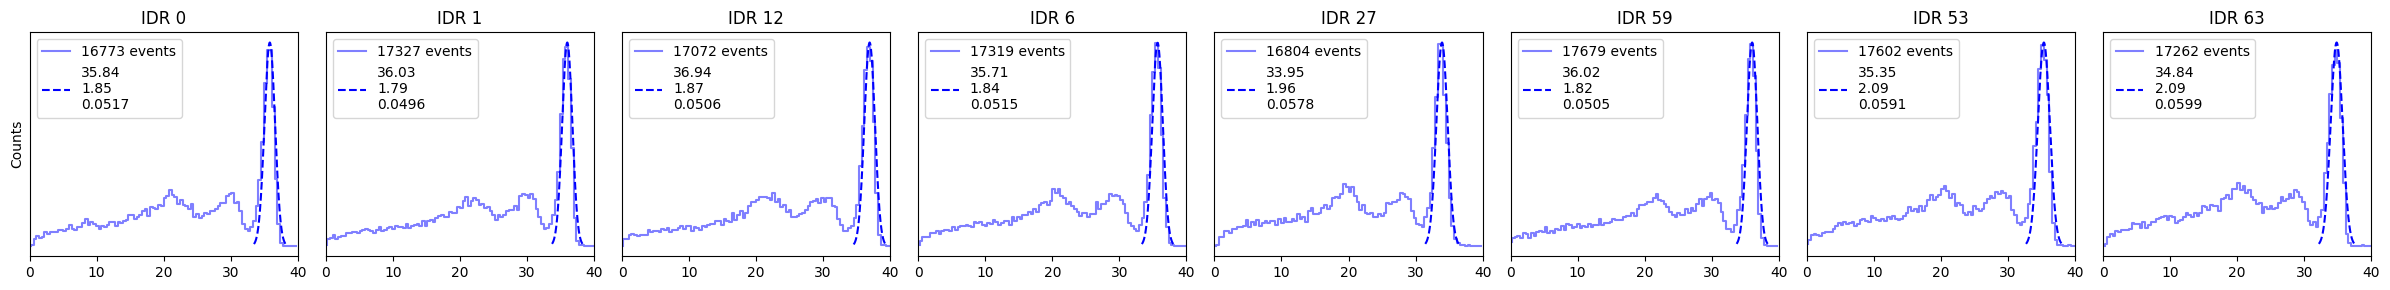

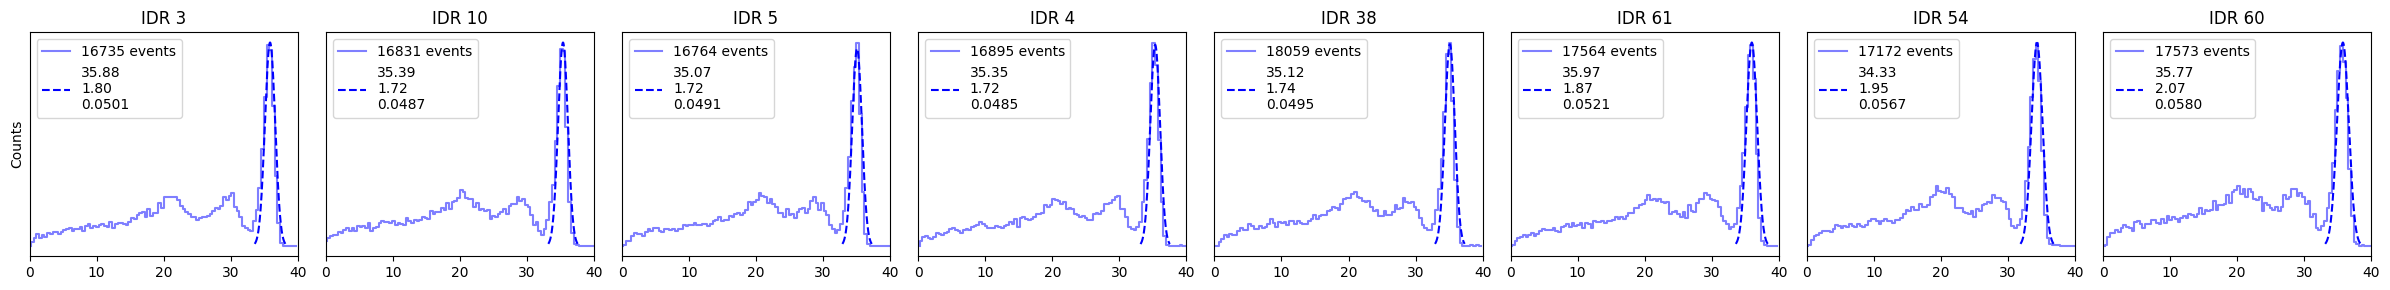

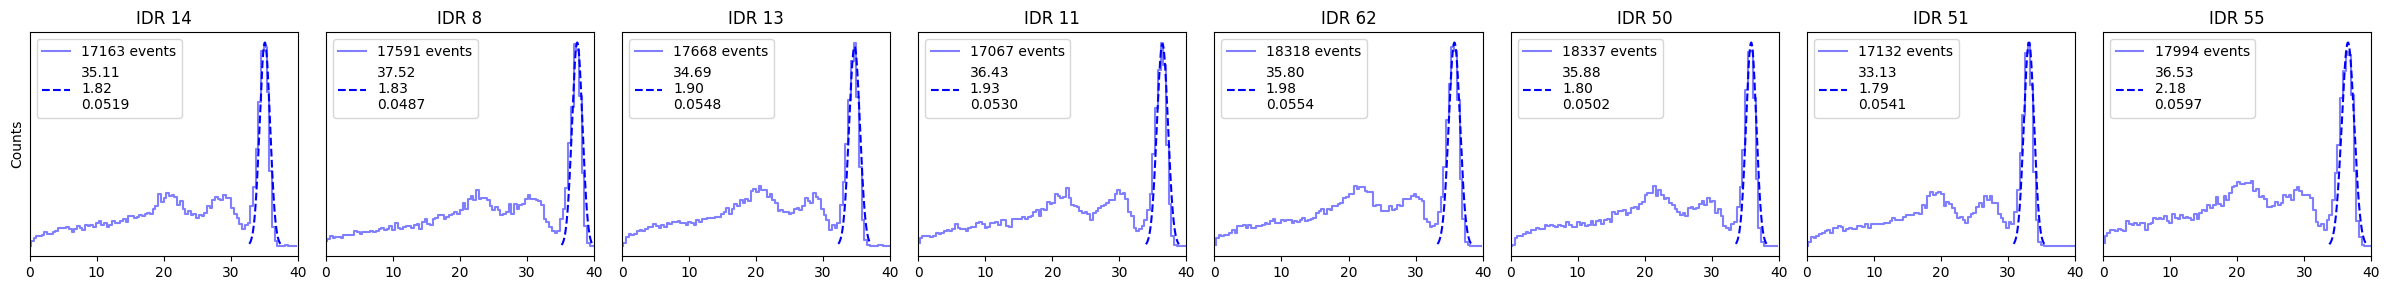

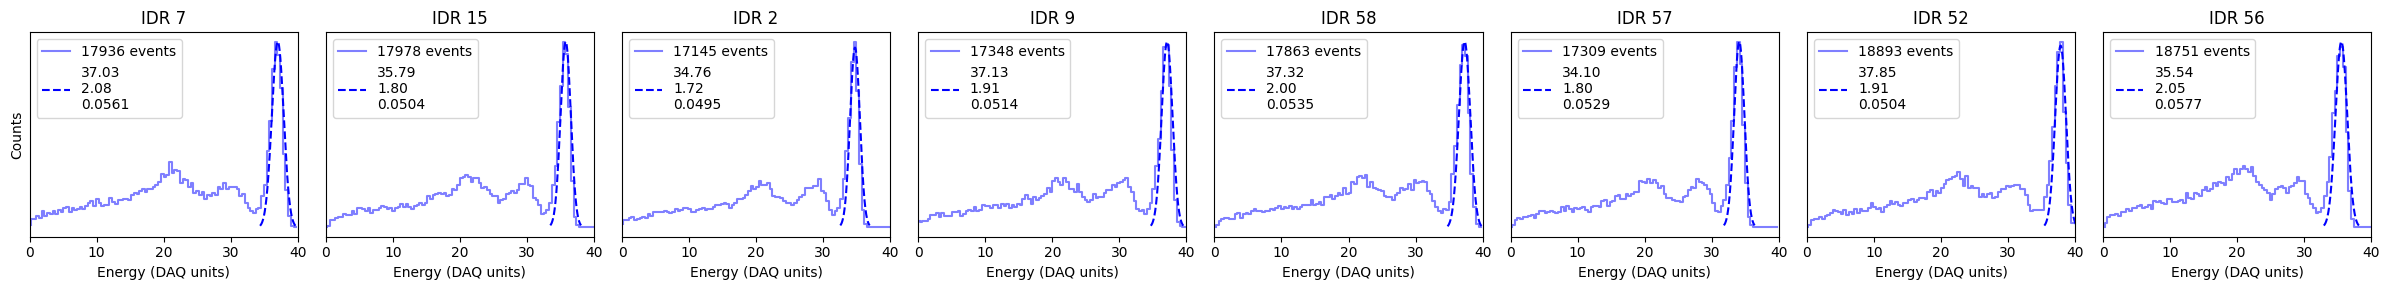

In [277]:
# Right module energy histograms
bins = np.linspace(0, 40, 100)
bincenters = (bins[:-1] + bins[1:]) / 2
for row in range(0, 8):
    list_indices = dict(sorted(
        ((k, v) for k, v in indices.items() if v[0] == row),
        key=lambda item: item[1][1]
    ))
    list_indices = list(list_indices.keys())
    fig, subplots = plt.subplots(1, 8, figsize=(24, 3))
    subplots = subplots.flatten()
    for i in range(8):
        id6 = list_indices[i]
        for dat, color, n in zip(datas_cut, colors, range(len(datas))):
            energies6 = dat[:, 4][dat[:, 5] == id6]
            hist, _ = np.histogram(energies6, bins=bins, range=(0, 40))
            subplots[i].step(bincenters, hist, color=color, alpha=0.5, label = f'{np.sum(hist)} events')
            if len(energies6) > 0:
                fit_p = findPhotopeak(hist, bincenters)
                plotting_bounds = np.linspace(fit_p[1] - 3 * fit_p[2], fit_p[1] + 3 * fit_p[2], 1000)
                fwhm = fit_p[2]*2.355
                energy_resolution = fwhm / fit_p[1]
                subplots[i].plot(plotting_bounds, gaussian(plotting_bounds, *fit_p), color=color, linestyle='--', label=f'{fit_p[1]:.2f}\n{fwhm:.2f}\n{energy_resolution:.4f}')
                eres[n].append(energy_resolution)
                photopeaks[n].append(fit_p[1])
                nevents[n].append(len(energies6))
                mask = (energies6 > fit_p[1] - 2.5 * fit_p[2]) & (energies6 < fit_p[1] + 2.5 * fit_p[2])
                neventsinpeak[n].append(np.sum(mask))
             
        subplots[i].set_title(f'IDR {id6}')
        subplots[i].legend()
       
    for i in range(8):
        subplots[i].set_xlim(0, 40)
        subplots[i].set_yticks([])
        if list_indices[i] + 896 == 852:
            subplots[i].set_ylim(0, 30)
        if i % 8 == 0:
            subplots[i].set_ylabel('Counts')
        if row % 4 == 3:
            subplots[i].set_xlabel('Energy (DAQ units)')

    plt.tight_layout()
    plt.show()

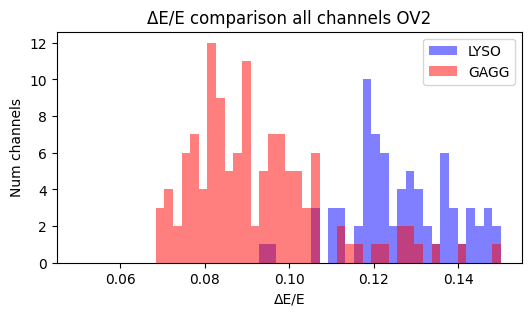

In [ ]:
# Energy resolution comparison
bins = np.linspace(0.05, 0.15, 50)
bincenters = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 3))
hist, bins = plt.hist(eres[0], bins=bins, range=(0, 0.2), color='blue', alpha=0.5, label='LYSO')[0:2]
popt, _ = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 0.01])
plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
#plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color='blue', linestyle='--', label=f'{popt[1]:.1f}\n{popt[2]*2.355:.1f}\n{popt[1]/popt[2]*2.355:.4f}')
plt.hist(eres[1], bins=bins, range=(0, 0.2), color='red', alpha=0.5, label='GAGG')
plt.legend()
plt.title('ΔE/E comparison all channels OV2')
plt.xlabel('ΔE/E')
plt.ylabel('Num channels')
plt.show()

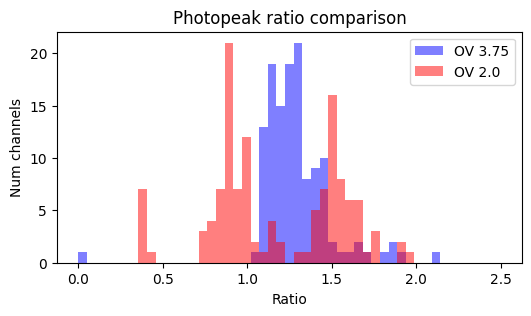

In [50]:
# Photopeak ratio comparison
bins = np.linspace(0, 2.5, 50)
bincenters = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 3))
pp0, pp1, pp2, pp3 = np.array(photopeaks[0]), np.array(photopeaks[1]), np.array(photopeaks[2]), np.array(photopeaks[3])
plt.hist(pp1 / pp0, bins=bins, color='blue', alpha=0.5, label='OV 3.75')[0:2]
plt.hist(pp3 / pp2, bins=bins, color='red', alpha=0.5, label='OV 2.0')
plt.legend()
plt.title('Photopeak ratio comparison')
plt.xlabel('Ratio')
plt.ylabel('Num channels')
plt.show()

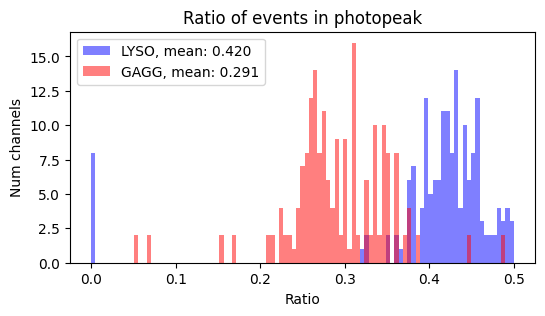

In [22]:
bins = np.linspace(0, 0.5, 100)
bincenters = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 3))
ratioLYSO = [neventsinpeak[0][i] / nevents[0][i] for i in range(len(nevents[0]))]
ratioGAGG = [neventsinpeak[1][i] / nevents[1][i] for i in range(len(nevents[1]))]
meanLYSO, meanGAGG = np.mean(ratioLYSO), np.mean(ratioGAGG)
plt.hist(ratioLYSO, bins=bins, range=(0, 0.2), color='blue', alpha=0.5, label=f'LYSO, mean: {meanLYSO:.3f}')
plt.hist(ratioGAGG, bins=bins, range=(0, 0.2), color='red', alpha=0.5, label=f'GAGG, mean: {meanGAGG:.3f}')
plt.legend()
plt.title('Ratio of events in photopeak')
plt.xlabel('Ratio')
plt.ylabel('Num channels')
plt.show()

In [442]:
# Photopeak cutter
cutrange = 2.5 # Sigma to cut on
datas_pcut = []
for data, name in zip(datas_cut, names):
    data_pcut = data.copy()
    maskL = np.zeros(len(data_pcut), dtype=bool)
    maskR = np.zeros(len(data_pcut), dtype=bool)
    # Precompute channel indices for efficiency
    idl = data_pcut[:, 2] % 128
    idr = data_pcut[:, 5] % 128

    # For each channel, fit photopeaks and update the mask for ALL events in data_pcut
    for i in range(0,64):
        # Left channel
        in_channelL = (idl == i)
        if np.sum(in_channelL) > 0:
            histL, binsL = np.histogram(data_pcut[in_channelL, 1], bins=100, range=(0, 40))
            fitL = findPhotopeak(histL, binsL)
            boundsL = [fitL[1] - cutrange * fitL[2], fitL[1] + cutrange * fitL[2]]
            this_maskL = in_channelL & (data_pcut[:, 1] > boundsL[0]) & (data_pcut[:, 1] < boundsL[1])
            maskL = maskL | this_maskL
        # Right channel
        in_channelR = (idr == i)
        if np.sum(in_channelR) > 0:
            histR, binsR = np.histogram(data_pcut[in_channelR, 4], bins=100, range=(0, 40))
            fitR = findPhotopeak(histR, binsR)
            boundsR = [fitR[1] - cutrange * fitR[2], fitR[1] + cutrange * fitR[2]]
            this_maskR = in_channelR & (data_pcut[:, 4] > boundsR[0]) & (data_pcut[:, 4] < boundsR[1])
            maskR = maskR | this_maskR

    data_pcut = data_pcut[maskL & maskR]
    datas_pcut.append(data_pcut)
    tofiledata = np.array(data_pcut[:, [2, 5, 6]], dtype=np.int16)
    
    tofiledata.tofile(f'{name}_pcut.bin')
print(len(datas_pcut[0]))
#print(len(datas_pcut[0]), len(datas_pcut[1]))


41499


41499 124


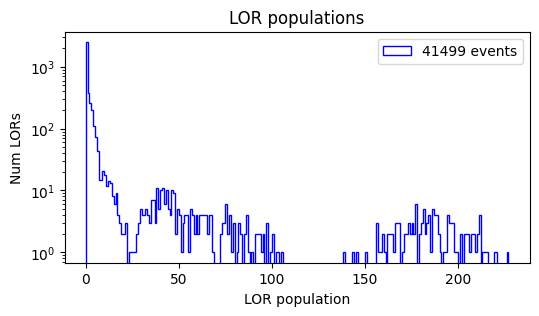

In [443]:
# Event counts per LOR
reldata = datas_pcut
ctrpopthreshold = 150
plt.figure(figsize=(6, 3))
for data, color, name in zip(reldata, colors, names):
    eventcounts = np.zeros((64, 64), dtype=np.int32)
    mask = (data[:, 2] % 128 < 64) & (data[:, 5] % 128 < 64)
    #mask = (data[:, 2] % 128 >= 64) & (data[:, 5] % 128 >= 64)
    chunk = data[mask]
    idls = np.asarray(chunk[:, 2], dtype=np.int32) % 128 % 64
    idrs = np.asarray(chunk[:, 5], dtype=np.int32) % 128 % 64
    np.add.at(eventcounts, (idls, idrs), 1)
    print(np.sum(eventcounts), np.sum(eventcounts > ctrpopthreshold))
    plt.hist(eventcounts.flatten(), bins = np.max(eventcounts.flatten()), 
        color = color, alpha = 1, histtype = 'step', linewidth = 1,
        #label = f'{name}: {np.sum(eventcounts)} events')
        label = f'{np.sum(eventcounts)} events')
plt.yscale('log')
#plt.xlim(0, 260)
#plt.xlim(0, 55)
plt.xlabel('LOR population')
plt.ylabel('Num LORs')
plt.title('LOR populations')
legend = plt.legend()
plt.show()


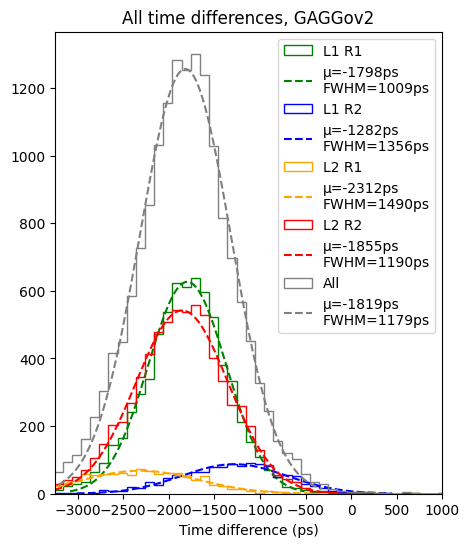

In [29]:
# Simple time diffs
index = 1 # Select data
data = datas_pcut[index] # Select data

half1=np.asarray(list(range(0, 27)) + list(range(28, 33)) + list(range(64, 73)) + list(range(76, 97)) + [74, 102])
def asichalf1(events, column):
    return events[np.isin(events[:, column] % 128, half1)]
def asichalf2(events, column):
    return events[~np.isin(events[:, column] % 128, half1)]
plt.figure(figsize=(5, 6))
bins = np.linspace(-10000, 10000, 200)
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]
halves11 = asichalf1(asichalf1(data, 2), 5)
halves12 = asichalf1(asichalf2(data, 2), 5)
halves21 = asichalf2(asichalf1(data, 2), 5)
halves22 = asichalf2(asichalf2(data, 2), 5)
hist, bins = plt.hist(halves11[:, 6], bins = bins, color = 'green', histtype = 'step', label = 'L1 R1')[0:2]
popt, _ = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 200], bounds = ([0, -3000, 0], [np.inf, 3000, np.inf]))
plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'green', linestyle = '--', label = f'μ={round(popt[1])}ps\nFWHM={round(popt[2]*2.355)}ps')
hist, bins = plt.hist(halves12[:, 6], bins = bins, color = 'blue', histtype = 'step', label = 'L1 R2')[0:2]
popt, _ = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 200], bounds = ([0, -3000, 0], [np.inf, 3000, np.inf]))
plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'blue', linestyle = '--', label = f'μ={round(popt[1])}ps\nFWHM={round(popt[2]*2.355)}ps')
hist, bins = plt.hist(halves21[:, 6], bins = bins, color = 'orange', histtype = 'step', label = 'L2 R1')[0:2]
popt, _ = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 200], bounds = ([0, -3000, 0], [np.inf, 3000, np.inf]))
plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'orange', linestyle = '--', label = f'μ={round(popt[1])}ps\nFWHM={round(popt[2]*2.355)}ps')
hist, bins = plt.hist(halves22[:, 6], bins = bins, color = 'red', histtype = 'step', label = 'L2 R2')[0:2]
popt, _ = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 200], bounds = ([0, -3000, 0], [np.inf, 3000, np.inf]))
plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'red', linestyle = '--', label = f'μ={round(popt[1])}ps\nFWHM={round(popt[2]*2.355)}ps')
hist, bins = plt.hist(data[:, 6], bins = bins, color = 'gray', histtype = 'step',  label = 'All')[0:2]
popt, _ = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 200], bounds = ([0, -3000, 0], [np.inf, 3000, np.inf]))
plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'gray', linestyle = '--', label = f'μ={round(popt[1])}ps\nFWHM={round(popt[2]*2.355)}ps')
plt.legend()
plt.xlim(-3250, 1000)
plt.title(f'All time differences, {names[index]}')
plt.xlabel('Time difference (ps)')
plt.show()

In [444]:
# CTR
data = datas_pcut[0]

def gaussian(x, a, b, c):
    return a * np.exp(-(x - b)**2 / (2 * c**2))
bins = np.linspace(-2500, 2500, 101)
bincenters = (bins[:-1] + bins[1:]) / 2

pairs = []
for i in range(len(eventcounts)):
    for j in range(len(eventcounts[i])):
        if eventcounts[i][j] > ctrpopthreshold:
            pairs.append((i, j))

fwhms = []
perchannelFWHMsL = [[] for _ in range(64)]
perchannelFWHMsR = [[] for _ in range(64)]
hdiffs = []
for pair in tqdm(pairs):
    lordata = data[(data[:, 2] % 128 % 64 == pair[0]) & (data[:, 5] % 128 % 64 == pair[1])]
    #hist = plt.hist(lordata[:, 6], bins = bins, color = 'gray', histtype = 'step')[0]
    hist = np.histogram(lordata[:, 6], bins = bins)[0]
    popt, pcov = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 200], bounds = ([0, -3000, 0], [np.inf, 3000, np.inf]))
    #print(popt)
    #plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
    #plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'gray', linestyle = '--', label = f'μ={round(popt[1])}ps\nFWHM={round(popt[2]*2.355)}ps')
    #break
    fwhms.append(np.abs(popt[2]*2.355))
    perchannelFWHMsL[pair[0]].append(np.abs(popt[2]*2.355))
    perchannelFWHMsR[pair[1]].append(np.abs(popt[2]*2.355))
    xdiff = np.abs(indices[pair[0] + 64][1] - (7 - indices[pair[1] + 64][1]))
    ydiff = np.abs(indices[pair[0] + 64][0] - indices[pair[1] + 64][0])
    hdiffs.append(np.sqrt(xdiff**2 + ydiff**2))
print(len(fwhms))


100%|██████████| 124/124 [00:00<00:00, 343.44it/s]

124


31 4 174


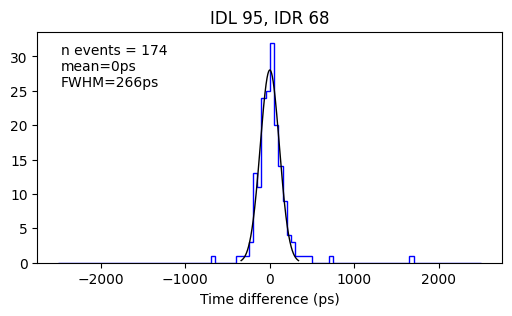

In [425]:
pairindex = np.random.randint(0, len(pairs))
idl, idr = pairs[pairindex]
lordata = data[(data[:, 2] % 128 % 64 == idl) & (data[:, 5] % 128 % 64 == idr)]
print(idl, idr, len(lordata))
plt.figure(figsize=(6, 3))
bins = np.linspace(-2500, 2500, 101)
bincenters = (bins[:-1] + bins[1:]) / 2
hist, bins = plt.hist(lordata[:, 6], bins = bins, color = 'blue', histtype = 'step')[0:2]
popt, _ = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 200], bounds = ([0, -3000, 0], [np.inf, 3000, np.inf]))
plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'black', linewidth = 1)
plt.text(0.05, 0.95, f'n events = {len(lordata)}\nmean={round(popt[1])}ps\nFWHM={round(popt[2]*2.355)}ps', fontsize = 10, transform = plt.gca().transAxes, ha = 'left', va = 'top')
plt.title(f'IDL {idl+64}, IDR {idr+64}')
plt.xlabel('Time difference (ps)')
plt.show()


[np.int64(15), np.int64(21)]


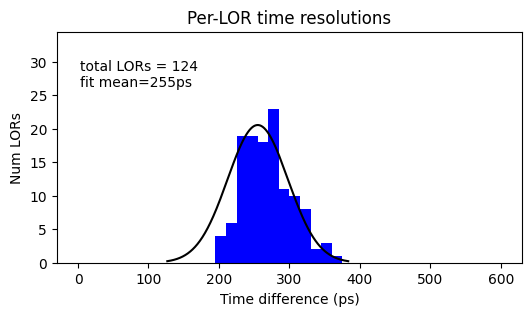

In [455]:
plt.figure(figsize=(6, 3))
bins = np.linspace(0, 600, 41)
bincenters = (bins[:-1] + bins[1:]) / 2
hist = np.histogram(fwhms, bins = bins)[0]
plt.bar(bincenters, hist, width = bins[1] - bins[0], color = 'blue')
fittingrange = [np.argmax(hist) - 3, np.argmax(hist) + 3]
print(fittingrange)
popt, _ = curve_fit(gaussian, bincenters[fittingrange[0]:fittingrange[1]], hist[fittingrange[0]:fittingrange[1]], p0=[np.max(hist), bincenters[np.argmax(hist)], 200])
plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'black')
plt.text(0.05, 0.95, f'\ntotal LORs = {len(fwhms)}\nfit mean={round(popt[1])}ps', fontsize = 10, transform = plt.gca().transAxes, ha = 'left', va = 'top')
plt.title(f'Per-LOR time resolutions')
plt.xlabel('Time difference (ps)')
plt.ylabel('Num LORs')
plt.ylim(0, 34.5)
plt.show()

In [446]:
numL = 0
numR = 0
for n in range(64):
    numL += len(perchannelFWHMsL[n])
    numR += len(perchannelFWHMsR[n])
print(numL, numR)

124 124


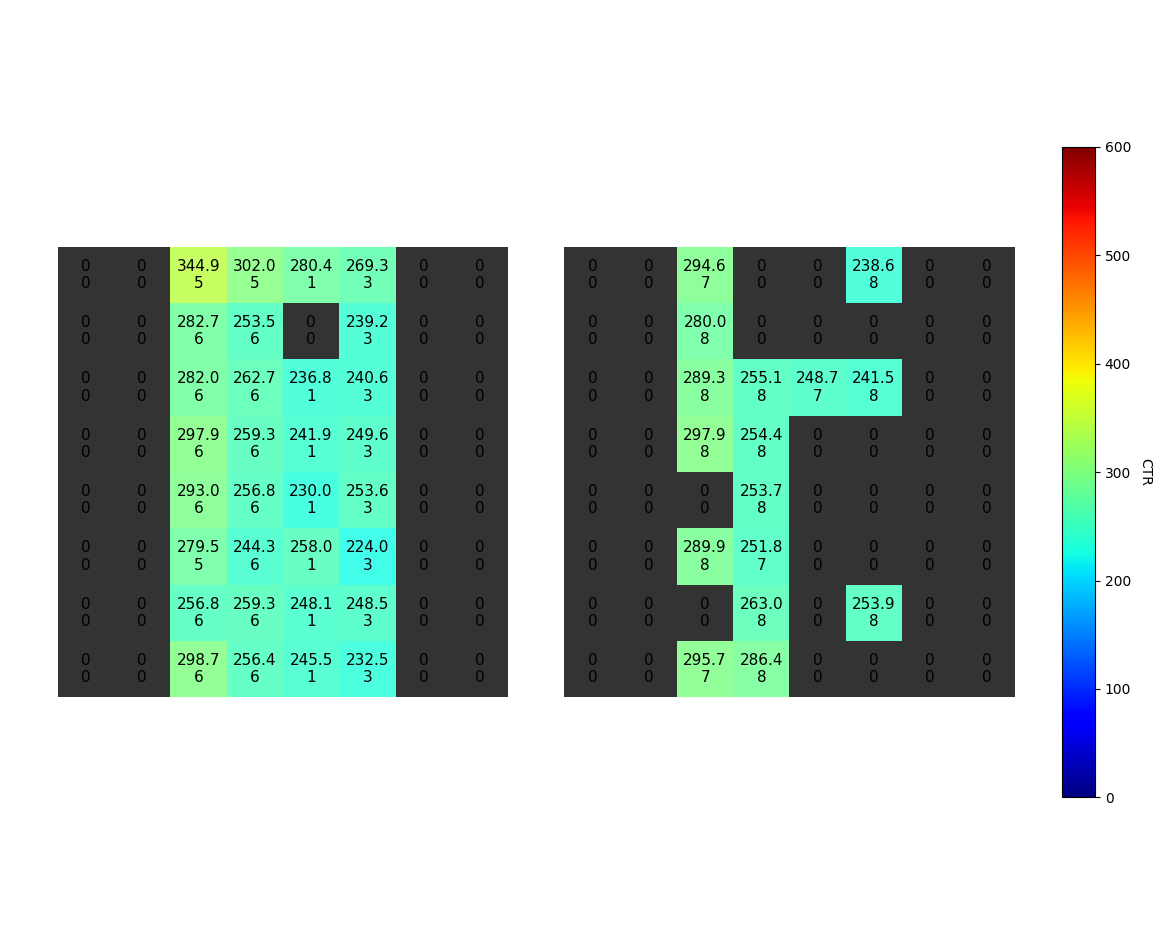

In [451]:
max_val = 600
fig, ax = plt.subplots(figsize=(14, 12))
for n in range(0, 64):
    y, x = indices[n]
    y = 15 - y
    if y >= 8:
        y += 0.4
    valL = np.mean(np.array(perchannelFWHMsL[n]))
    valR = np.mean(np.array(perchannelFWHMsR[n]))
    colorL = plt.cm.jet(valL / max_val)
    colorR = plt.cm.jet(valR / max_val)
    rectl = Rectangle((x, y), 1, 1, linewidth=0.0, edgecolor='black', facecolor=colorL, alpha=0.8)
    if np.isnan(valL):
        valL = 0
    ax.text(x + 0.5, y + 0.5, f'{round(valL, 1)}\n{len(perchannelFWHMsL[n - 64])}', fontsize=11, ha='center', va='center')
    
    y, x = indices[n+64]
    x = 7 - x
    if y >= 8:
        y += 0.4
    rectr = Rectangle((x + 9, y), 1, 1, linewidth=0.0, edgecolor='black', facecolor=colorR, alpha=0.8)
    ax.add_patch(rectl)
    ax.add_patch(rectr)

    if np.isnan(valR):
        valR = 0
    ax.text(x + 9.5, y + 0.5, f'{round(valR, 1)}\n{len(perchannelFWHMsR[n - 64])}', fontsize=11, ha='center', va='center')

plt.tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.ylim(0, 16)
plt.xlim(0, 8)
plt.axis('equal')

# Add colorbar
sm = ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=0, vmax = max_val))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.0)
cbar.set_label('CTR', rotation=270, labelpad=15)

#plt.title(f'{name} Activity heatmaps')
plt.show()

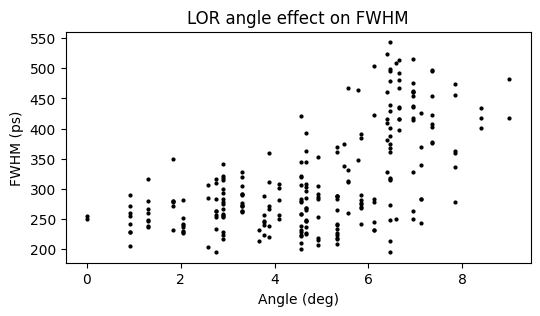

In [295]:
plt.figure(figsize=(6, 3))
hdiffs = np.array(hdiffs)
angles = np.arctan2(hdiffs * 3.2, 200) * 180 / np.pi
plt.scatter(angles, fwhms, s = 4, color = 'black')
plt.xlabel('Angle (deg)')
plt.ylabel('FWHM (ps)')
plt.title('LOR angle effect on FWHM')
plt.show()